In [24]:
from pathlib import Path
import shutil
from src.vlm_score import compute_vlm_score
import json
import matplotlib.pyplot as plt

In [6]:
run_dir = Path("/Users/jonathansickert/git/VIGA/output/16-25-52_target_description/renders")
target_dir = Path("../runs_furniture_placement")
target_dir.mkdir(exist_ok=True)


for step in run_dir.iterdir():
    if step.is_dir(): 
        for render in step.iterdir():
            if render.is_file() and render.suffix == ".png":
                shutil.copy(render, target_dir / f"color_{step.name}.png")
                

In [5]:
TARGET_IMAGE = "/Users/jonathansickert/git/3DFrontBench/dataset/0f661df2-0f41-47a4-830c-7444f4a33a03_LivingDiningRoom-12554/color.png"
RUNS_DIR = Path("/Users/jonathansickert/git/3DFrontBench/runs_furniture_placement")

results = {}

for step in RUNS_DIR.iterdir():
    if step.is_file() and step.suffix == ".png":
        vlm_score = compute_vlm_score(
            target_path=TARGET_IMAGE,
            render_path=step
        )
        results[step.name] = vlm_score

In [11]:
with open("../outputs/results_runs_furniture_placement_vlm.json", "w") as f:
    json.dump(results, f, indent=2)

In [31]:
with open("../outputs/results_runs_furniture_placement_vlm.json", "r") as f:
    vlm_results = json.load(f)


vlm_results = {int(k.split("_")[-1].replace(".png", "")) : v[0] for k, v in vlm_results.items()}
avg_vlm_results = {}
for step, score in vlm_results.items():
    score = json.loads(score)
    metrics = [
        score["object_count"],
        score["object_placement"],
        score["object_scale"],
        score["object_orientation"],
    ]

    avg_score = sum(metrics) / len(metrics)
    avg_vlm_results[step] = avg_score

human_eval = {
    3: (0, 1),
    6: (0, 0),
    9: (0, 1),
    12: (1, 4),
    15: (1, 4),
    18: (0, 0),
    21: (0, 0),
    24: (1, 2),
    27: (1, 4),
    30: (0, 0),
    33: (0, 0),
    37: (0, 0),
    40: (2, 6),
    43: (0, 2),
    46: (2, 6),
    49: (1, 3),
    52: (2, 6),
    55: (1, 2),
    58: (1, 4),
    61: (2, 6),
    65: (1, 5),
}

avg_human_eval = {step: sum(scores) / len(scores) for step, scores in human_eval.items()}

avg_vlm_results = dict(sorted(avg_vlm_results.items()))
avg_human_eval = dict(sorted(avg_human_eval.items()))


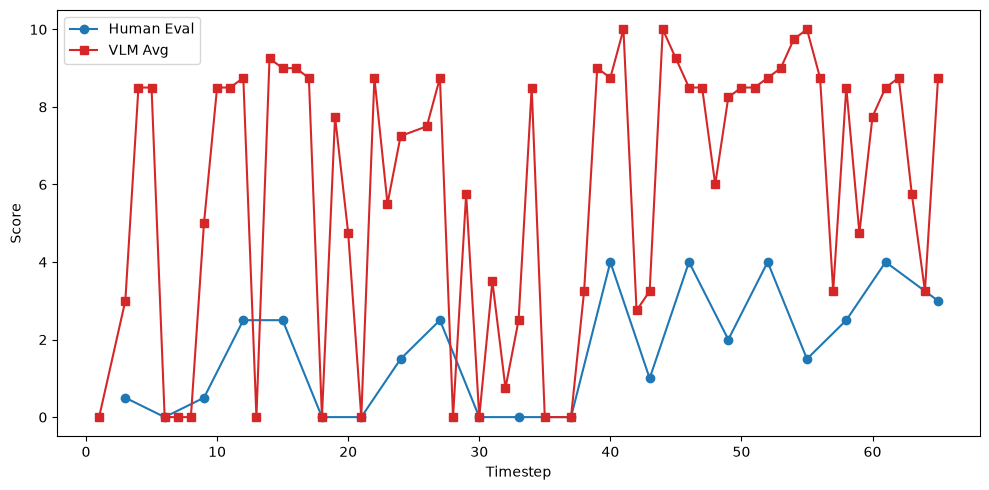

In [40]:
human_x = list(avg_human_eval.keys())
human_y = list(avg_human_eval.values())

vlm_x = list(avg_vlm_results.keys())
vlm_y = list(avg_vlm_results.values())

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel("Timestep")
ax1.set_ylabel("Score")

ax1.plot(human_x, human_y, marker="o", color="tab:blue", label="Human Eval")
ax1.plot(vlm_x, vlm_y, marker="s", color="tab:red", label="VLM Avg")

ax1.legend(loc="upper left")
fig.tight_layout()

fig.tight_layout()

In [39]:
common = [t for t in avg_human_eval if t in avg_vlm_results]
mean_distance = sum(abs(avg_human_eval[t] - avg_vlm_results[t]) for t in common) / len(common)
mean_distance

3.880952380952381